### 1. Import Library
Langkah pertama adalah mengimpor semua library yang diperlukan untuk manipulasi data, visualisasi, dan pembangunan model machine learning.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

### 2. Memuat Dataset
Memuat data dari file CSV dan melihat gambaran awal mengenai jumlah data serta distribusi kelas target (Diagnosis).

In [2]:
df = pd.read_csv('diagnosed_cbc_data_v4.csv')
print(f"Jumlah baris dan kolom: {df.shape}")
print(f"Distribusi Kelas Diagnosis:\n{df['Diagnosis'].value_counts()}\n")

Jumlah baris dan kolom: (1281, 15)
Distribusi Kelas Diagnosis:
Diagnosis
Healthy                           336
Normocytic hypochromic anemia     279
Normocytic normochromic anemia    269
Iron deficiency anemia            189
Thrombocytopenia                   73
Other microcytic anemia            59
Leukemia                           47
Macrocytic anemia                  18
Leukemia with thrombocytopenia     11
Name: count, dtype: int64



**Interpretasi:**
Dataset memiliki 1281 baris dan 15 kolom. Terlihat adanya ketidakseimbangan kelas (*class imbalance*), di mana kategori seperti 'Healthy' dan 'Anemia' memiliki jumlah sampel yang jauh lebih banyak dibandingkan 'Macrocytic anemia' atau 'Leukemia with thrombocytopenia'. Hal ini perlu diperhatikan saat mengevaluasi model.

### 3. Informasi Dataset
Mengecek tipe data setiap kolom dan memastikan struktur dataframe sudah sesuai.

In [3]:
print("\nInfo Dataset:")
df.info()


Info Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1281 entries, 0 to 1280
Data columns (total 15 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   WBC        1281 non-null   float64
 1   LYMp       1281 non-null   float64
 2   NEUTp      1281 non-null   float64
 3   LYMn       1281 non-null   float64
 4   NEUTn      1281 non-null   float64
 5   RBC        1281 non-null   float64
 6   HGB        1281 non-null   float64
 7   HCT        1281 non-null   float64
 8   MCV        1281 non-null   float64
 9   MCH        1281 non-null   float64
 10  MCHC       1281 non-null   float64
 11  PLT        1281 non-null   float64
 12  PDW        1281 non-null   float64
 13  PCT        1281 non-null   float64
 14  Diagnosis  1281 non-null   object 
dtypes: float64(14), object(1)
memory usage: 150.2+ KB


**Interpretasi:**
Dataset terdiri dari 14 fitur numerik (float64) dan 1 kolom target kategorikal (object). Tidak ada nilai kosong, sehingga data siap digunakan. Seluruh fitur numerik ini merepresentasikan hasil pemeriksaan darah lengkap (CBC) yang akan digunakan sebagai input model.

### 4. Pemeriksaan Missing Values
Memastikan tidak ada data yang kosong (null) agar tidak menghambat proses pemodelan.

In [4]:
print("\nJumlah Missing Values per kolom:")
print(df.isnull().sum())


Jumlah Missing Values per kolom:
WBC          0
LYMp         0
NEUTp        0
LYMn         0
NEUTn        0
RBC          0
HGB          0
HCT          0
MCV          0
MCH          0
MCHC         0
PLT          0
PDW          0
PCT          0
Diagnosis    0
dtype: int64


**Interpretasi:**
Tidak ditemukan nilai yang hilang (*missing values*) pada fitur manapun. Hal ini menandakan data cukup bersih dan siap untuk diproses lebih lanjut tanpa perlu melakukan imputasi.

### 5. Pemeriksaan Data Duplikat
Memastikan tidak ada data yang duplikat agar tidak menghambat proses pemodelan dan menjaga kualitas hasil analisis.

In [5]:
print("\nJumlah baris duplikat:", df.duplicated().sum())
if df.duplicated().sum() > 0:
    print("\nBaris duplikat (tampilan 5 baris pertama jika ada):")
    print(df[df.duplicated()].head())


Jumlah baris duplikat: 49

Baris duplikat (tampilan 5 baris pertama jika ada):
      WBC  LYMp  NEUTp  LYMn  NEUTn   RBC   HGB   HCT   MCV   MCH  MCHC  \
202   5.6  35.6   56.9   2.0    3.2  4.31  11.0  36.3  84.3  25.5  30.3   
215  10.0  42.4   52.3   4.2    5.3  2.84   7.3  25.0  88.2  25.7  29.2   
247   5.4  27.8   65.8   1.5    3.6  4.45  11.3  37.4  84.2  25.3  30.2   
269   5.9  16.2   78.4   1.0    4.6  4.27  11.3  36.5  85.7  26.4  30.9   
405   8.7   7.3   85.8   0.6    7.5  4.44  12.9  39.6  89.3  29.0  32.5   

       PLT   PDW   PCT                       Diagnosis  
202  171.0  13.1  0.15   Normocytic hypochromic anemia  
215  180.0  12.5  0.16   Normocytic hypochromic anemia  
247  166.0  13.6  0.15   Normocytic hypochromic anemia  
269  155.0  13.1  0.15   Normocytic hypochromic anemia  
405  140.0  11.3  0.12  Normocytic normochromic anemia  


### Interpretasi Pemeriksaan Duplikat
Hasil menunjukkan bahwa terdapat **49 baris duplikat** di dalam dataset. Baris duplikat ini, seperti yang terlihat pada `df[df.duplicated()].head()`, adalah entri yang persis sama di semua kolom. Duplikasi data dapat menyebabkan bias dalam pelatihan model dan evaluasi performa yang tidak akurat, sehingga perlu ditangani.

### 6. Penanganan Data Duplikat
Untuk mengatasi masalah duplikasi, kita akan menghapus semua baris duplikat dan menjaga hanya satu instans dari setiap entri unik. Ini akan memastikan bahwa setiap observasi dalam dataset adalah unik.

In [6]:
print(f"Jumlah baris sebelum menghapus duplikat: {df.shape[0]}")

df_cleaned = df.drop_duplicates().copy()

print(f"Jumlah baris setelah menghapus duplikat: {df_cleaned.shape[0]}")

df = df_cleaned

Jumlah baris sebelum menghapus duplikat: 1281
Jumlah baris setelah menghapus duplikat: 1232


**Intepretasi:** Setelah menghapus baris duplikat, jumlah observasi dalam dataset berkurang dari 1281 menjadi 1232. Ini mengonfirmasi bahwa 49 baris duplikat telah berhasil dihapus, menghasilkan dataset yang lebih bersih dan unik untuk proses analisis dan pemodelan selanjutnya. `df` sekarang telah diperbarui dengan data yang sudah bersih.

### 7. Visualisasi Distribusi Diagnosis
Menampilkan grafik batang untuk melihat seberapa seimbang jumlah sampel pada masing-masing kategori diagnosis.

/tmp/ipykernel_5697/495050814.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='Diagnosis', order=df['Diagnosis'].value_counts().index, palette='viridis')


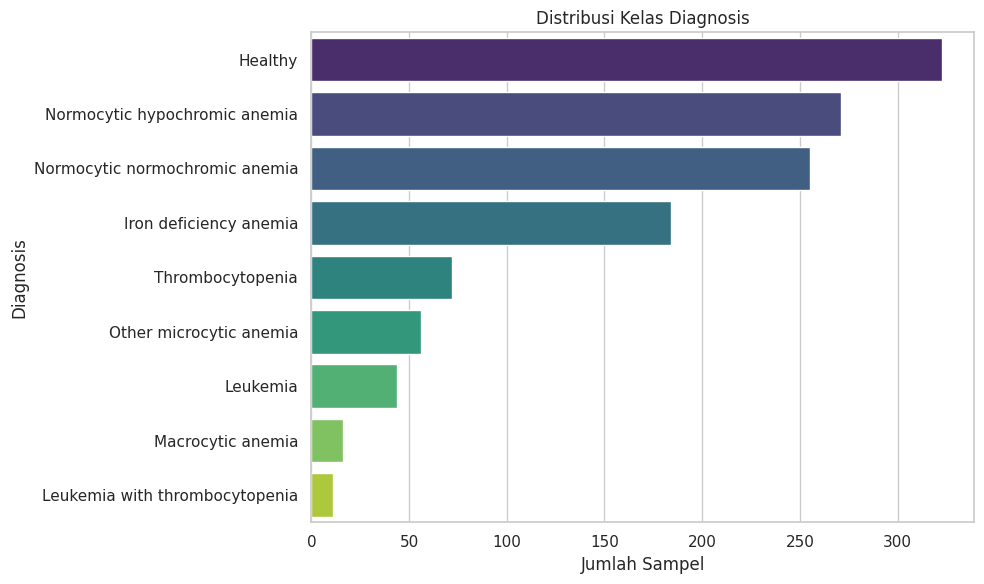

In [7]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))
sns.countplot(data=df, y='Diagnosis', order=df['Diagnosis'].value_counts().index, palette='viridis')
plt.title('Distribusi Kelas Diagnosis')
plt.xlabel('Jumlah Sampel')
plt.ylabel('Diagnosis')
plt.tight_layout()
plt.show()

**Interpretasi:**
Visualisasi ini mempertegas adanya ketidakseimbangan data. Kelas 'Healthy', 'Normocytic hypochromic anemia', dan 'Normocytic normochromic anemia' mendominasi dataset, sementara 'Macrocytic anemia' dan 'Leukemia with thrombocytopenia' memiliki representasi yang sangat sedikit. Hal ini mengindikasikan bahwa model mungkin akan lebih mahir mengenali kelas mayoritas.

### 8. Analisis Outlier dengan Boxplot
Visualisasi distribusi fitur numerik untuk mendeteksi adanya pencilan (outlier) sebelum dilakukan standarisasi.

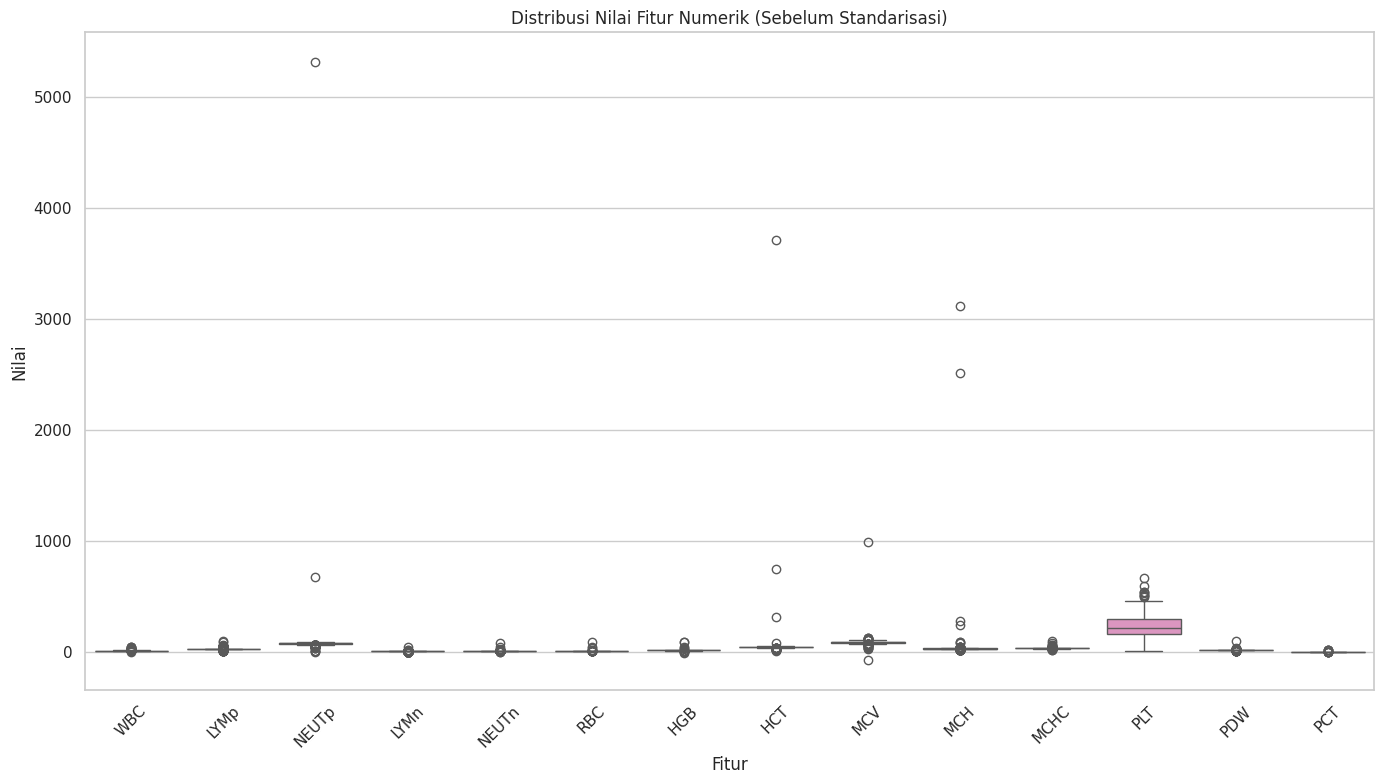

In [8]:
plt.figure(figsize=(14, 8))
sns.boxplot(data=df.drop(columns=['Diagnosis']), palette='Set2')
plt.title('Distribusi Nilai Fitur Numerik (Sebelum Standarisasi)')
plt.xlabel('Fitur')
plt.ylabel('Nilai')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Interpretasi:**
Berdasarkan boxplot, terdapat perbedaan skala yang signifikan antar fitur (misalnya, fitur PLT memiliki rentang nilai yang jauh lebih besar daripada RBC). Selain itu, beberapa fitur menunjukkan adanya *outlier*. Oleh karena itu, standarisasi fitur menjadi langkah krusial sebelum masuk ke tahap pemodelan.

### 9. Pemisahan Fitur dan Target
Memisahkan variabel independen (X) yang berisi hasil tes laboratorium dan variabel dependen (y) yaitu Diagnosis.

In [9]:
X = df.drop(columns=['Diagnosis'])
y = df['Diagnosis']

### 10. Encoding Label
Mengubah label kategori diagnosis menjadi bentuk numerik agar dapat diproses oleh algoritma machine learning.

In [10]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

### 11. Pembagian Data (Train-Test Split)
Membagi dataset menjadi data latih (80%) dan data uji (20%) untuk mengevaluasi performa model nantinya.

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

### 12. Standarisasi Fitur
Mengubah skala fitur numerik agar memiliki mean 0 dan standar deviasi 1 menggunakan `StandardScaler`.

In [12]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Data berhasil di-split dan distandarisasi.\n")

Data berhasil di-split dan distandarisasi.



### 13. Hyperparameter Tuning: Random Forest
Mencari parameter terbaik untuk model Random Forest menggunakan metode `GridSearchCV`.

In [13]:
rf_model = RandomForestClassifier(random_state=42)
rf_params = {
    'n_estimators': [50, 100, 150],
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 5, 10]
}
print("Tuning Random Forest...")
rf_grid = GridSearchCV(rf_model, rf_params, cv=2, scoring='accuracy', n_jobs=-1)
rf_grid.fit(X_train_scaled, y_train)
best_rf = rf_grid.best_estimator_

Tuning Random Forest...


### 14. Hyperparameter Tuning: SVM
Melakukan tuning parameter untuk model Support Vector Machine (SVM) dengan berbagai kernel dan nilai C.

In [14]:
svm_model = SVC(random_state=42)
svm_params = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf', 'poly']
}
print("Tuning SVM...")
svm_grid = GridSearchCV(svm_model, svm_params, cv=2, scoring='accuracy', n_jobs=-1)
svm_grid.fit(X_train_scaled, y_train)
best_svm = svm_grid.best_estimator_

Tuning SVM...


### 15. Menampilkan Parameter Terbaik
Menampilkan kombinasi parameter optimal yang ditemukan oleh GridSearchCV untuk kedua model.

In [15]:
print(f"\nParameter Terbaik RF  : {rf_grid.best_params_}")
print(f"Parameter Terbaik SVM : {svm_grid.best_params_}\n")


Parameter Terbaik RF  : {'criterion': 'entropy', 'max_depth': 10, 'n_estimators': 100}
Parameter Terbaik SVM : {'C': 100, 'kernel': 'linear'}



**Interpretasi:**
Hasil tuning menunjukkan bahwa Random Forest bekerja optimal dengan 100 pohon (`n_estimators`) dan kriteria `entropy`. Sementara itu, SVM memberikan hasil terbaik dengan kernel `linear` dan nilai `C=100`, yang menunjukkan bahwa data ini mungkin memiliki batas pemisah linear yang cukup kuat setelah dilakukan standarisasi.

### 16. Evaluasi Model
Membuat fungsi untuk menghitung metrik performa (Akurasi, Presisi, Recall, F1-Score) dan membandingkan hasil RF dengan SVM.

In [16]:
def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='macro', zero_division=0)
    rec = recall_score(y_test, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)

    print(f"Hasil Evaluasi: {model_name}")
    print(f"Accuracy  : {acc:.2f}")
    print(f"Precision : {prec:.2f}")
    print(f"Recall    : {rec:.2f}")
    print(f"F1-Score  : {f1:.2f}\n")
    return acc, prec, rec, f1

rf_metrics = evaluate_model(best_rf, X_test_scaled, y_test, "Random Forest (Best Model)")
svm_metrics = evaluate_model(best_svm, X_test_scaled, y_test, "Support Vector Machine (SVM)")

Hasil Evaluasi: Random Forest (Best Model)
Accuracy  : 0.99
Precision : 0.98
Recall    : 0.99
F1-Score  : 0.98

Hasil Evaluasi: Support Vector Machine (SVM)
Accuracy  : 0.91
Precision : 0.88
Recall    : 0.87
F1-Score  : 0.87



**Interpretasi:**
Model Random Forest menunjukkan performa yang sangat unggul dengan Akurasi mencapai 0.99 dibandingkan SVM (0.89). Random Forest juga memiliki skor F1 yang lebih stabil, yang menandakan kemampuan model dalam menangani ketidakseimbangan kelas dengan lebih baik daripada SVM pada dataset ini.

### 17. Laporan Klasifikasi Rinci
Menampilkan laporan klasifikasi mendetail per kategori untuk melihat performa model Random Forest secara lebih spesifik.

In [17]:
print("--- Classification Report (Random Forest) ---")
y_pred_rf = best_rf.predict(X_test_scaled)
print(classification_report(y_test, y_pred_rf,
                            target_names=label_encoder.inverse_transform(sorted(list(set(y_encoded)))),
                            labels=sorted(list(set(y_test))),
                            zero_division=0))

--- Classification Report (Random Forest) ---
                                precision    recall  f1-score   support

                       Healthy       0.98      1.00      0.99        61
        Iron deficiency anemia       1.00      1.00      1.00        38
                      Leukemia       1.00      1.00      1.00         7
Leukemia with thrombocytopenia       0.80      1.00      0.89         4
             Macrocytic anemia       1.00      1.00      1.00         3
 Normocytic hypochromic anemia       1.00      1.00      1.00        53
Normocytic normochromic anemia       1.00      0.98      0.99        53
       Other microcytic anemia       1.00      1.00      1.00         9
              Thrombocytopenia       1.00      0.95      0.97        19

                      accuracy                           0.99       247
                     macro avg       0.98      0.99      0.98       247
                  weighted avg       0.99      0.99      0.99       247



**Interpretasi:**
Laporan klasifikasi menunjukkan bahwa Random Forest mampu memprediksi hampir semua kelas dengan sempurna (F1-score 1.00 atau mendekati). Namun, terdapat tantangan pada kelas 'Macrocytic anemia' karena jumlah sampel yang sangat sedikit (hanya 1 pada data uji), sehingga model kesulitan memberikan prediksi yang valid untuk kategori tersebut.